# NLCD Land Use and Spatial Comparison Analysis

This notebook uses National Land Cover Database land-cover data to identify potential ghost forest transition pixels in the Chesapeake Bay region. For this project, potential ghost forest transition pixels are defined as areas that were classified as forest in 2001 and wetland in 2021.

After identifying these transition pixels, the notebook combines the NLCD-derived land-cover transition data with NOAA relative sea level rise trends and Chesapeake Bay Program salinity trends. NOAA tide gauge stations are used as the spatial anchor for the analysis. A 15-kilometer buffer is created around each tide gauge station, and the notebook counts potential ghost forest transition pixels and nearby salinity stations within each buffer.

The final output is a combined comparison table linking relative sea level rise, average nearby salinity change, and potential ghost forest transition pixel counts.

In [1]:
# --- 1. SETUP, STUDY AREA, AND DATA RETRIEVAL ---

from pathlib import Path
import os
import warnings

# Suppress FutureWarnings to reduce unnecessary notebook output
warnings.simplefilter(action="ignore", category=FutureWarning)

# Define project folders
DATA_DIR = Path("../Data")
OTHER_MATERIALS_DIR = Path("../OtherMaterials")

# Send the HyRiver/pygeohydro cache file to the Data folder
os.environ["HYRIVER_CACHE_NAME"] = str(DATA_DIR / "aiohttp_cache.sqlite")

import pandas as pd
import pygeohydro as gh
import geopandas as gpd
from shapely.geometry import box, Point
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

# Create a bounding box for the Chesapeake Bay region
bbox = [-77.5, 36.5, -75.0, 40.0]

# Convert the bounding box into a GeoDataFrame using standard latitude/longitude coordinates
geometry = gpd.GeoDataFrame({"geometry": [box(*bbox)]}, crs="EPSG:4326")

# Fetch NLCD land-cover data for 2001 and 2021
print("Fetching NLCD data from USGS...")
nlcd_dict = gh.nlcd_bygeom(
    geometry,
    resolution=30,
    years={"cover": [2001, 2021]}
)

# The returned object is a dictionary, so access the data for the first geometry
nlcd = nlcd_dict[0]

print("...Fetching complete!")

Fetching NLCD data from USGS...
...Fetching complete!


## Setup, Study Area, and NLCD Data Retrieval

This code cell imports the libraries needed for the NLCD land-cover and spatial analysis workflow. The `pandas` and `geopandas` libraries are used for tabular and spatial data processing, `pygeohydro` is used to retrieve NLCD data, `shapely` is used to create geometric objects, and `cartopy` and `matplotlib` are used for mapping.

The code also defines the project `Data` and `OtherMaterials` folders. Because this notebook is stored inside the `Code` folder, the path `../Data` points back to the main project folder and then into the `Data` folder. The HyRiver cache location is set to `../Data/aiohttp_cache.sqlite` so the downloaded NLCD cache file is stored in the project `Data` folder instead of being written to a separate default cache folder.

The bounding box defines the Chesapeake Bay study area using longitude and latitude coordinates. The notebook then retrieves NLCD land-cover data for 2001 and 2021 at 30-meter resolution. These two years are used to identify areas that changed from forest to wetland over the study period.

In [2]:
# --- 2. SEPARATE YEARS, DEFINE LAND-COVER CLASSES, AND CREATE TRANSITION MASK ---

# Separate the returned NLCD layers by year
ds2001 = nlcd["cover_2001"]
ds2021 = nlcd["cover_2021"]

# Define NLCD forest classes:
# 41 = Deciduous Forest, 42 = Evergreen Forest, 43 = Mixed Forest
was_forest = ds2001.isin([41, 42, 43])

# Define NLCD wetland classes:
# 90 = Woody Wetlands, 95 = Emergent Herbaceous Wetlands
is_wetland = ds2021.isin([90, 95])

# Identify pixels that were forest in 2001 and wetland in 2021
ghost_forest_mask = was_forest & is_wetland

## Identifying Potential Ghost Forest Transition Pixels

This code cell separates the NLCD data into the 2001 and 2021 land-cover layers. It then defines the land-cover classes used to represent forest and wetland areas.

The forest classes include deciduous forest, evergreen forest, and mixed forest. The wetland classes include woody wetlands and emergent herbaceous wetlands. The transition mask identifies pixels that were classified as forest in 2001 and wetland in 2021.

For this project, these pixels are treated as potential ghost forest transition pixels. This does not prove that every selected pixel is a true ghost forest, because NLCD land-cover change alone cannot confirm tree mortality or the exact ecological cause of conversion. However, the transition from forest to wetland provides a useful spatial proxy for possible ghost forest expansion.

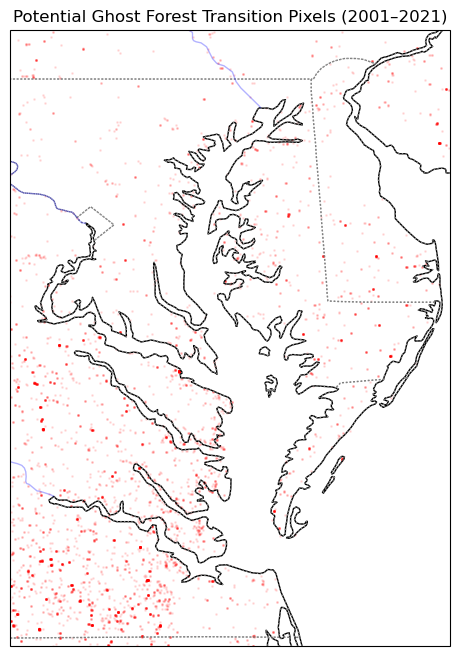

Number of 30m pixels identified as potential ghost forest transition: 4915.0


In [3]:
# --- 3. APPLY TRANSITION MASK AND MAP POTENTIAL GHOST FOREST PIXELS ---

# Create the transition map:
# 1.0 for potential ghost forest transition pixels, NaN otherwise
transition_map = ghost_forest_mask.where(ghost_forest_mask == True, np.nan).astype(float)

# Stack x and y dimensions, then drop NaNs to keep only transition pixels
valid_coords = transition_map.stack(pixel=("x", "y")).dropna("pixel")

# Extract longitude and latitude values for transition pixels
lons = valid_coords.x.values
lats = valid_coords.y.values

# Create a map of the transition pixels
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic context
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor="black")
ax.add_feature(cfeature.STATES, linestyle=":", edgecolor="gray")
ax.add_feature(cfeature.RIVERS, edgecolor="blue", alpha=0.3)

# Plot transition pixels
ax.scatter(
    lons,
    lats,
    s=1,
    color="red",
    alpha=0.1,
    transform=ccrs.PlateCarree()
)

# Set map extent to the Chesapeake Bay study area
ax.set_extent([-77.5, -75.0, 36.5, 40.0], crs=ccrs.PlateCarree())

plt.title("Potential Ghost Forest Transition Pixels (2001–2021)")

# Save and display the map
plt.savefig(
    OTHER_MATERIALS_DIR / "NLCD_Potential_Ghost_Forest_Transition_Map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Count the number of transition pixels
count = np.nansum(transition_map.values)
print(f"Number of 30m pixels identified as potential ghost forest transition: {count}")

## Mapping Potential Ghost Forest Transition Pixels

This code cell applies the forest-to-wetland transition mask and converts the selected NLCD pixels into coordinate points that can be mapped. Pixels that meet the transition condition are assigned a value of 1, while all other pixels are treated as missing values. This makes it possible to isolate only the potential ghost forest transition pixels.

The map shows the spatial distribution of pixels that changed from forest in 2001 to wetland in 2021. This provides an initial visual check of where potential ghost forest transitions are concentrated within the Chesapeake Bay study area.

The printed pixel count gives the total number of 30-meter pixels that met the transition rule. Because each NLCD pixel represents a 30-meter by 30-meter area, this count represents the number of mapped land-cover cells rather than the number of individual trees or forest stands.

This notebook stops at the NLCD transition-mapping step. The final project report combines these transition pixels with the RSLR and salinity datasets, creates the 15-kilometer tide gauge buffers, and performs the final spatial comparison and correlation analysis.